In [1]:
# =============================================================================
# Cell 1: Install Dependencies — A100 optimized
# Run once at the start of each Colab session.
# =============================================================================

import subprocess, sys

def pip(*args):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet"] + list(args),
        check=False
    )

print("Installing packages...")

pip("torch==2.3.1", "torchvision==0.18.1", "torchaudio==2.3.1",
    "--index-url", "https://download.pytorch.org/whl/cu121")
print("  torch done")

# Fix numpy FIRST before anything else — flash-attn needs numpy <2.0
pip("numpy==1.26.4")
print("  numpy pinned to 1.26.4 (binary compat fix)")

# Pin triton + compatible bitsandbytes (fixes 'No module named triton.ops')
pip("triton==2.3.1")
print("  triton done")

packages = [
    "transformers==4.41.2",
    "accelerate==0.32.0",
    "bitsandbytes==0.43.1",
    "peft==0.11.1",
    "rouge-score",
    "bert-score",
    "nltk",
    "scipy",
    "sentencepiece",
    "protobuf",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "lxml",
    "icalendar",
    "python-dateutil",
    "dateparser",
    "deepeval",
    "python-dotenv",
    "datasets>=2.20.0",
]
for pkg in packages:
    pip(pkg)
    print(f"  {pkg.split('>=')[0].split('==')[0]} done")

# Install flash-attn AFTER numpy is pinned
print("  installing flash-attn (may take 1-3 min)...")
pip("flash-attn==2.5.9.post1", "--no-build-isolation")
print("  flash-attn done")

import nltk
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

# Force reload numpy to pick up the pinned version
import importlib, numpy
importlib.reload(numpy)

import torch
print()
print(f"PyTorch    : {torch.__version__}")
print(f"numpy      : {numpy.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

try:
    import flash_attn
    print(f"FlashAttn  : {flash_attn.__version__}")
except ImportError:
    print("FlashAttn  : NOT found — will use standard attention (still works)")

print("\nAll packages ready.")

Installing packages...
  torch done
  numpy pinned to 1.26.4 (binary compat fix)
  triton done
  transformers done
  accelerate done
  bitsandbytes done
  peft done
  rouge-score done
  bert-score done
  nltk done
  scipy done
  sentencepiece done
  protobuf done
  scikit-learn done
  pandas done
  matplotlib done
  seaborn done
  tqdm done
  lxml done
  icalendar done
  python-dateutil done
  dateparser done
  deepeval done
  python-dotenv done
  datasets done
  installing flash-attn (may take 1-3 min)...
  flash-attn done

PyTorch    : 2.3.1+cu121
numpy      : 2.0.2
CUDA       : True
GPU        : NVIDIA A100-SXM4-80GB
VRAM       : 85.1 GB
FlashAttn  : 2.5.9.post1

All packages ready.


In [1]:
# Cell 2: Mount Drive and verify all required files exist

from google.colab import drive
import os

drive.mount("/content/drive", force_remount=False)
print("Google Drive mounted.")

# Edit this if your folder path is different
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/298-Capstone Project/DATA-298B"

if not os.path.isdir(DRIVE_PROJECT_PATH):
    raise FileNotFoundError(
        f"Drive folder not found: {DRIVE_PROJECT_PATH}\n"
        "Edit DRIVE_PROJECT_PATH to match your exact folder path."
    )

print(f"\nDrive folder found: {DRIVE_PROJECT_PATH}")
print("\nContents:")
for item in sorted(os.listdir(DRIVE_PROJECT_PATH)):
    full = os.path.join(DRIVE_PROJECT_PATH, item)
    kind = "folder" if os.path.isdir(full) else "file"
    print(f"  [{kind}] {item}")

# Set all paths
PHASE4_MODEL_PATH = os.path.join(DRIVE_PROJECT_PATH, "phase4_model", "final_model")
TEST_JSONL        = os.path.join(DRIVE_PROJECT_PATH, "phase4_outputs", "test.jsonl")
OUTPUT_DIR        = os.path.join(DRIVE_PROJECT_PATH, "phase4_eval_outputs")
BASE_MODEL_NAME   = "Qwen/Qwen2.5-14B-Instruct"
DEEPEVAL_N        = 100
DEMO_DATE         = "2026-04-01 10:00:00"

HF_CACHE_DIR = os.path.join(DRIVE_PROJECT_PATH, "hf_cache")
os.makedirs(HF_CACHE_DIR, exist_ok=True)
os.environ["TRANSFORMERS_CACHE"] = HF_CACHE_DIR
os.environ["HF_HOME"]            = HF_CACHE_DIR
os.environ["HF_DATASETS_CACHE"]  = HF_CACHE_DIR
os.environ["TOKENIZERS_PARALLELISM"] = "false"

for sub in ["summaries", "ics", "plots", "csv"]:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

FT_CACHE   = os.path.join(OUTPUT_DIR, "ft_inference_cache.jsonl")
BASE_CACHE = os.path.join(OUTPUT_DIR, "base_inference_cache.jsonl")

# Verify required files
print("\nVerifying required files...")
errors = []
for fname in ["adapter_config.json", "adapter_model.safetensors", "tokenizer_config.json"]:
    fpath = os.path.join(PHASE4_MODEL_PATH, fname)
    if not os.path.isfile(fpath):
        errors.append(f"  MISSING: {fpath}")
    else:
        print(f"  OK: {fname}")

if not os.path.isfile(TEST_JSONL):
    errors.append(f"  MISSING: {TEST_JSONL}")
    errors.append("  --> Upload test.jsonl from your 4090 to Drive first")
else:
    print(f"  OK: test.jsonl")

if errors:
    for e in errors:
        print(e)
    raise FileNotFoundError("Fix missing files above before continuing.")

print("\nAll files verified.")
print(f"\nSettings:")
print(f"  Model path  : {PHASE4_MODEL_PATH}")
print(f"  Test JSONL  : {TEST_JSONL}")
print(f"  Output dir  : {OUTPUT_DIR}")
print(f"  HF cache    : {HF_CACHE_DIR}")

Mounted at /content/drive
Google Drive mounted.

Drive folder found: /content/drive/MyDrive/298-Capstone Project/DATA-298B

Contents:
  [file] ami_public_manual_1.6.2.zip
  [folder] hf_cache
  [folder] phase1_model
  [folder] phase1_outputs
  [folder] phase2_model
  [folder] phase2_outputs
  [folder] phase4_eval_outputs
  [folder] phase4_model
  [folder] phase4_outputs
  [folder] proto_final_model
  [folder] transcript_summarizer

Verifying required files...
  OK: adapter_config.json
  OK: adapter_model.safetensors
  OK: tokenizer_config.json
  OK: test.jsonl

All files verified.

Settings:
  Model path  : /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_model/final_model
  Test JSONL  : /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_outputs/test.jsonl
  Output dir  : /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs
  HF cache    : /content/drive/MyDrive/298-Capstone Project/DATA-298B/hf_cache


In [2]:
# Cell 3: Imports and GPU check

import re, gc, json, time, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from typing import List, Dict, Optional
from tqdm.auto import tqdm
from nltk.tokenize import sent_tokenize
from icalendar import Calendar, Event, Todo
import dateparser
import getpass

matplotlib.rcParams.update({"figure.dpi": 150})
warnings.filterwarnings("ignore")

print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"torch   : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("Imports OK.")

numpy   : 1.26.4
pandas  : 2.2.2
torch   : 2.3.1+cu121
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB
VRAM    : 85.1 GB
Imports OK.


In [3]:
# Cell 4: OpenAI API key (hidden input) + shared utility functions

import os

OPENAI_API_KEY = getpass.getpass(
    "Enter OpenAI API key for DeepEval (press Enter to skip): "
).strip()
if not OPENAI_API_KEY:
    print("No key provided. DeepEval will be skipped.")
else:
    print("OpenAI API key accepted.")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY


# Utility functions used by all inference and evaluation cells

_ACTIONS_JSON_RE = re.compile(
    r"ACTIONS_JSON:\s*(\[.*?\])",
    re.DOTALL | re.IGNORECASE,
)

P4_SYSTEM_PROMPT = (
    "You are a professional meeting minutes assistant. "
    "Your output must contain exactly these sections in order: "
    "ABSTRACT, DECISIONS, PROBLEMS, ACTIONS, ACTIONS_JSON. "
    "ACTIONS_JSON must be a valid JSON array."
)
P4_USER_INSTRUCTION = (
    "Given the meeting transcript below, produce:\n"
    "  ABSTRACT:   A concise paragraph summarising the meeting.\n"
    "  DECISIONS:  Bullet list of decisions made.\n"
    "  PROBLEMS:   Bullet list of problems or risks raised.\n"
    "  ACTIONS:    Bullet list formatted as [Owner] - task - Due: deadline.\n"
    "  ACTIONS_JSON: JSON array, each item has keys: "
    "owner, task, deadline, discussed_at_sec.\n"
    "Rules:\n"
    "  - Do not fabricate facts not in the transcript.\n"
    "  - Set owner/deadline to TBD when not mentioned.\n"
    "  - ACTIONS_JSON must parse as valid JSON.\n"
    "  - discussed_at_sec should be a float or 0.0 if unknown."
)


def create_p4_prompt(transcript: str) -> str:
    return (
        f"<|im_start|>system\n{P4_SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n"
        f"{P4_USER_INSTRUCTION}\n\n"
        f"TRANSCRIPT:\n{transcript}\n"
        f"<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


def clean_structured_summary(raw: str) -> str:
    headers  = ["ABSTRACT:", "DECISIONS:", "ACTIONS:", "PROBLEMS:", "ACTION:"]
    earliest = len(raw)
    for h in headers:
        pos = raw.upper().find(h)
        if pos != -1 and pos < earliest:
            earliest = pos
    return raw[earliest:].strip() if earliest < len(raw) else raw.strip()


def parse_actions_json(cleaned: str):
    m = _ACTIONS_JSON_RE.search(cleaned)
    if not m:
        return [], False, "ACTIONS_JSON block not found"
    candidate = m.group(1).strip()
    try:
        return json.loads(candidate), True, ""
    except json.JSONDecodeError as e:
        try:
            fixed = candidate[:candidate.rfind("]") + 1]
            return json.loads(fixed), True, f"repaired: {e}"
        except Exception:
            return [], False, str(e)


def create_p4_target(rec: Dict) -> str:
    parts = []
    for label, key in [
        ("ABSTRACT",  "summary_abstract"),
        ("DECISIONS", "summary_decisions"),
        ("PROBLEMS",  "summary_problems"),
        ("ACTIONS",   "summary_actions"),
    ]:
        val = (rec.get(key) or "").strip()
        if val:
            parts.append(f"{label}:\n{val}")
    action_items = rec.get("action_items") or []
    if action_items:
        entries = []
        for ai in action_items:
            entries.append({
                "owner":            str(ai.get("owner", "TBD")),
                "task":             str(ai.get("task", ""))[:300],
                "deadline":         str(ai.get("deadline", "TBD")),
                "discussed_at_sec": float(ai.get("discussed_at_sec", 0.0) or 0.0),
            })
        parts.append(f"ACTIONS_JSON:\n{json.dumps(entries, indent=2)}")
    return "\n\n".join(parts)


def load_jsonl(path: str) -> List[Dict]:
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def load_cache(path: str) -> Dict:
    cached = {}
    if os.path.isfile(path):
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        obj = json.loads(line)
                        cached[obj["meeting_id"]] = obj
                    except Exception:
                        continue
    return cached


#Batched inference — processes BATCH_SIZE meetings in parallel

def run_inference_batch(
    model,
    tokenizer,
    records: List[Dict],
    batch_size: int = 6,
    max_new_tokens: int = 384,
    chunk_size: int = 512,
    max_seq: int = 3072,
) -> Dict[str, Dict]:
    """
    Run generation on a list of records in batches.
    Returns dict: meeting_id -> inference result dict.
    Uses left-padding so all samples in a batch generate correctly.
    """
    original_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"          # required for batch generation

    all_results = {}

    for batch_start in range(0, len(records), batch_size):
        batch = records[batch_start : batch_start + batch_size]

        # Build prompts, truncate if needed
        prompts = []
        for rec in batch:
            transcript = rec.get("transcript", "")
            prompt     = create_p4_prompt(transcript)
            if len(tokenizer.encode(prompt, add_special_tokens=False)) > max_seq:
                tokens      = tokenizer.encode(transcript, add_special_tokens=False)
                first_chunk = tokenizer.decode(tokens[:chunk_size], skip_special_tokens=True)
                prompt      = create_p4_prompt(first_chunk)
            prompts.append(prompt)

        inputs = tokenizer(
            prompts,
            max_length=max_seq,
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(model.device)

        prompt_len = inputs["input_ids"].shape[1]   # padded prompt length

        with torch.no_grad():
            out_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                min_new_tokens=20,
                do_sample=False,
                repetition_penalty=1.1,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Decode only the newly generated tokens for each sample
        for j, rec in enumerate(batch):
            gen_ids = out_ids[j][prompt_len:]
            raw     = tokenizer.decode(gen_ids, skip_special_tokens=False)
            if "<|im_start|>assistant" in raw:
                raw = raw.split("<|im_start|>assistant")[-1]
            raw     = raw.replace("<|im_end|>", "").strip()
            cleaned = clean_structured_summary(raw)
            actions_json, json_valid, json_error = parse_actions_json(cleaned)
            all_results[rec["meeting_id"]] = {
                "cleaned_output": cleaned,
                "actions_json":   actions_json,
                "json_valid":     json_valid,
                "json_error":     json_error,
            }

    tokenizer.padding_side = original_padding_side
    return all_results


print("Utilities ready.")



def mean_of(results: List[Dict], key: str) -> float:
    vals = [r[key] for r in results if r.get(key) is not None]
    return float(np.mean(vals)) if vals else float("nan")


print("Utilities ready.")

Enter OpenAI API key for DeepEval (press Enter to skip): ··········
OpenAI API key accepted.
Utilities ready.
Utilities ready.


In [4]:
# Cell 5: Load test records from Drive

print("Loading test records...")
test_records = load_jsonl(TEST_JSONL)
test_map     = {r["meeting_id"]: r for r in test_records}
print(f"Test meetings loaded: {len(test_records)}")

# Quick sanity check on first record
_first = test_records[0]
print(f"\nFirst record:")
print(f"  meeting_id  : {_first['meeting_id']}")
print(f"  data_source : {_first.get('data_source', 'n/a')}")
print(f"  transcript  : {len(_first.get('transcript', ''))} chars")
print(f"  has abstract: {bool(_first.get('summary_abstract', '').strip())}")

Loading test records...
Test meetings loaded: 762

First record:
  meeting_id  : LongBeachCC_11222016_16-1045
  data_source : meetingbank
  transcript  : 2085 chars
  has abstract: True


In [6]:
# Cell 5b: Reload all inference caches from Drive

# Define FLAN-T5 cache paths (normally set in Cell 7c)
FLANT5_BASE_NAME  = "google/flan-t5-large"
FLANT5_FT_PATH    = os.path.join(DRIVE_PROJECT_PATH, "proto_final_model")
FLANT5_FT_CACHE   = os.path.join(OUTPUT_DIR, "flant5_ft_cache.jsonl")
FLANT5_BASE_CACHE = os.path.join(OUTPUT_DIR, "flant5_base_cache.jsonl")

# Load all 4 caches
ft_cached          = load_cache(FT_CACHE)
base_cached        = load_cache(BASE_CACHE)
flant5_ft_cached   = load_cache(FLANT5_FT_CACHE)
flant5_base_cached = load_cache(FLANT5_BASE_CACHE)

print(f"Qwen FT        : {len(ft_cached)} meetings")
print(f"Qwen Base      : {len(base_cached)} meetings")
print(f"FLAN-T5 FT     : {len(flant5_ft_cached)} meetings")
print(f"FLAN-T5 Base   : {len(flant5_base_cached)} meetings")

# Verify all complete
total = len(test_records)
for label, cache in [
    ("Qwen FT",      ft_cached),
    ("Qwen Base",    base_cached),
    ("FLAN-T5 FT",   flant5_ft_cached),
    ("FLAN-T5 Base", flant5_base_cached),
]:
    status = "COMPLETE" if len(cache) == total else f"⚠ INCOMPLETE ({len(cache)}/{total})"
    print(f"  {label:<15}: {status}")

Qwen FT        : 762 meetings
Qwen Base      : 762 meetings
FLAN-T5 FT     : 762 meetings
FLAN-T5 Base   : 762 meetings
  Qwen FT        : COMPLETE
  Qwen Base      : COMPLETE
  FLAN-T5 FT     : COMPLETE
  FLAN-T5 Base   : COMPLETE


In [ ]:
# =============================================================================
# Cell 6: Fine-tuned model inference — A100, fixed meta tensor error
# =============================================================================

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import time, threading

BATCH_SIZE = 6
SAVE_EVERY = 20

PROGRESS_LOG = os.path.join(OUTPUT_DIR, "ft_inference_progress.txt")

def log(msg: str):
    ts   = datetime.now().strftime("%H:%M:%S")
    line = f"[{ts}] {msg}"
    print(line, flush=True)
    with open(PROGRESS_LOG, "a") as f:
        f.write(line + "\n")

print("=" * 70)
print(f"Fine-tuned model inference  [A100 | batch_size={BATCH_SIZE}]")
print("=" * 70)

ft_cached  = load_cache(FT_CACHE)
ft_missing = [r for r in test_records if r["meeting_id"] not in ft_cached]
print(f"Already cached : {len(ft_cached)}")
print(f"To generate    : {len(ft_missing)}")

if not ft_missing:
    print("All fine-tuned outputs already cached — skipping.")
else:
    _ft_done  = threading.Event()
    _ft_error = [None]

    def _ft_job():
        try:
            # ── Tokenizer ────────────────────────────────────────────────
            log(f"Loading tokenizer from: {PHASE4_MODEL_PATH}")
            tok = AutoTokenizer.from_pretrained(
                PHASE4_MODEL_PATH, trust_remote_code=True
            )
            if tok.pad_token is None:
                tok.pad_token = tok.eos_token
            tok.padding_side = "left"
            log(f"Tokenizer loaded. Vocab: {len(tok)}")

            # ── Flash Attention 2 ─────────────────────────────────────────
            try:
                import flash_attn
                attn_impl = "flash_attention_2"
                log(f"Flash Attention 2 : ENABLED ✓ ({flash_attn.__version__})")
            except ImportError:
                attn_impl = "eager"
                log("Flash Attention 2 : not available, using standard attention")

            # ── Load base model ───────────────────────────────────────────
            # FIX: use device_map="cuda:0" instead of "auto" to avoid
            # meta tensor error when PeftModel wraps the base model
            log("Loading base model in 4-bit NF4...")
            bnb = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
            )
            base_for_ft = AutoModelForCausalLM.from_pretrained(
                BASE_MODEL_NAME,
                quantization_config=bnb,
                device_map="cuda:0",            # ← FIX: explicit device, not "auto"
                low_cpu_mem_usage=True,         # ← FIX: prevents meta tensor issue
                trust_remote_code=True,
                attn_implementation=attn_impl,
            )
            log("Base model loaded. Applying LoRA adapter...")
            ft_model = PeftModel.from_pretrained(
                base_for_ft,
                PHASE4_MODEL_PATH,
                is_trainable=False,             # ← FIX: inference only
            )
            ft_model.config.use_cache = True
            ft_model.eval()
            log(f"Fine-tuned model ready. "
                f"VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB / "
                f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

            # ── Reload missing list fresh inside thread ───────────────────
            missing_now = [r for r in test_records
                           if r["meeting_id"] not in load_cache(FT_CACHE)]
            total   = len(missing_now)
            done    = 0
            buffer  = {}
            t_start = time.time()
            log(f"Starting inference on {total} meetings...")

            for b_start in range(0, total, BATCH_SIZE):
                batch   = missing_now[b_start : b_start + BATCH_SIZE]
                t0      = time.time()

                prompts = []
                for rec in batch:
                    transcript = rec.get("transcript", "")
                    prompt     = create_p4_prompt(transcript)
                    ids        = tok.encode(prompt, add_special_tokens=False)
                    if len(ids) > 3072:
                        t_ids  = tok.encode(transcript, add_special_tokens=False)
                        chunk  = tok.decode(t_ids[:512], skip_special_tokens=True)
                        prompt = create_p4_prompt(chunk)
                    prompts.append(prompt)

                inputs     = tok(
                    prompts,
                    max_length=3072,
                    truncation=True,
                    padding=True,
                    return_tensors="pt",
                ).to(ft_model.device)
                prompt_len = inputs["input_ids"].shape[1]

                with torch.no_grad():
                    out_ids = ft_model.generate(
                        **inputs,
                        max_new_tokens=384,
                        min_new_tokens=20,
                        do_sample=False,
                        repetition_penalty=1.1,
                        use_cache=True,
                        pad_token_id=tok.eos_token_id,
                    )

                t1       = time.time()
                per_item = (t1 - t0) / len(batch)

                for j, rec in enumerate(batch):
                    mid     = rec["meeting_id"]
                    gen_ids = out_ids[j][prompt_len:]
                    raw     = tok.decode(gen_ids, skip_special_tokens=False)
                    if "<|im_start|>assistant" in raw:
                        raw = raw.split("<|im_start|>assistant")[-1]
                    raw     = raw.replace("<|im_end|>", "").strip()
                    cleaned = clean_structured_summary(raw)
                    actions_json, json_valid, json_error = parse_actions_json(cleaned)
                    entry = {
                        "meeting_id":     mid,
                        "cleaned_output": cleaned,
                        "actions_json":   actions_json,
                        "json_valid":     json_valid,
                        "json_error":     json_error,
                        "reference":      create_p4_target(rec),
                        "gen_time_sec":   round(per_item, 2),
                        "model":          "finetuned",
                    }
                    buffer[mid]    = entry
                    ft_cached[mid] = entry

                done += len(batch)

                if len(buffer) >= SAVE_EVERY or done == total:
                    with open(FT_CACHE, "a", encoding="utf-8") as cf:
                        for e in buffer.values():
                            cf.write(json.dumps(e, ensure_ascii=False) + "\n")
                    buffer.clear()

                elapsed = time.time() - t_start
                rate    = done / elapsed
                eta     = (total - done) / rate if rate > 0 else 0
                log(f"Progress: {done}/{total} ({done/total*100:.1f}%) | "
                    f"{per_item:.1f}s/meeting | "
                    f"ETA: {eta/60:.0f}min")

            log(f"DONE — {total} meetings in {(time.time()-t_start)/60:.1f}min")

            del ft_model, base_for_ft
            gc.collect()
            torch.cuda.empty_cache()
            log("VRAM cleared.")

        except Exception:
            import traceback
            _ft_error[0] = traceback.format_exc()
            log(f"ERROR:\n{_ft_error[0]}")
        finally:
            _ft_done.set()

    _ft_thread = threading.Thread(target=_ft_job, daemon=True, name="infer-ft")
    _ft_thread.start()

    print(f"\nInference running in background thread.")
    print(f"Progress log : {PROGRESS_LOG}")
    print(f"Safe to close laptop if background execution is enabled.")

Fine-tuned model inference  [A100 | batch_size=6]
Already cached : 336
To generate    : 426
[00:51:33] Loading tokenizer from: /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_model/final_model

Inference running in background thread.
Progress log : /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs/ft_inference_progress.txt

Safe to lock laptop — background execution keeps kernel alive.
Run the monitoring cell below to check progress anytime.



In [ ]:
# Cell 6b: Monitor inference progress — safe to run anytime

def show_progress():
    cached     = load_cache(FT_CACHE)
    total      = len(test_records)
    done       = len(cached)
    pct        = done / total * 100 if total else 0
    bar        = ("█" * int(pct // 5)).ljust(20)

    print(f"{'='*55}")
    print(f"  Fine-tuned inference progress")
    print(f"  [{bar}] {done}/{total} ({pct:.1f}%)")
    print(f"{'='*55}")

    # Last 10 lines of log
    if os.path.isfile(PROGRESS_LOG):
        with open(PROGRESS_LOG) as f:
            lines = f.readlines()
        print(f"\nLast 10 log lines:")
        for l in lines[-10:]:
            print(f"  {l.rstrip()}")
    else:
        print("No log file yet — inference may still be starting up.")

    # Thread status
    try:
        status = "RUNNING ✓" if _ft_thread.is_alive() else "COMPLETED ✓"
        if _ft_error[0]:
            status = f"FAILED ✗"
            print(f"\nError:\n{_ft_error[0]}")
        print(f"\nBackground thread : {status}")
    except NameError:
        print("\nThread not in scope — if you reconnected, re-run Cell 6 to resume.")

show_progress()

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


[03:12:54] Tokenizer loaded. Vocab: 151665
[03:12:54] Flash Attention 2 : ENABLED ✓ (2.5.9.post1)
  Fine-tuned inference progress
  [████████████████████] 762/762 (100.0%)
[03:12:54] Loading base model in 4-bit NF4 (no adapter)...

Last 10 log lines:
  [03:00:18] Progress: 384/426 (90.1%) | 20.7s/meeting | ETA: 13min
  [03:02:12] Progress: 390/426 (91.5%) | 19.0s/meeting | ETA: 11min
  [03:04:02] Progress: 396/426 (93.0%) | 18.4s/meeting | ETA: 9min
  [03:05:43] Progress: 402/426 (94.4%) | 16.8s/meeting | ETA: 7min
  [03:07:39] Progress: 408/426 (95.8%) | 19.3s/meeting | ETA: 5min
  [03:09:08] Progress: 414/426 (97.2%) | 14.9s/meeting | ETA: 4min
  [03:11:06] Progress: 420/426 (98.6%) | 19.6s/meeting | ETA: 2min
  [03:12:54] Progress: 426/426 (100.0%) | 18.0s/meeting | ETA: 0min
  [03:12:54] DONE — 426 meetings in 129.1min
  [03:12:54] VRAM cleared.

Background thread : COMPLETED ✓


In [ ]:
# =============================================================================
# Cell 7: Base model inference — A100 optimized, background thread
# Waits for Cell 6 (FT inference) to finish before loading base model.
# =============================================================================

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import time, threading

BATCH_SIZE_BASE = 6
BASE_LOG = os.path.join(OUTPUT_DIR, "base_inference_progress.txt")

def log_base(msg: str):
    ts   = datetime.now().strftime("%H:%M:%S")
    line = f"[{ts}] {msg}"
    print(line, flush=True)
    with open(BASE_LOG, "a") as f:
        f.write(line + "\n")

print("=" * 70)
print(f"Base model inference  [A100 | batch_size={BATCH_SIZE_BASE}]")
print("=" * 70)

# ── Wait for FT thread to finish first (VRAM safety) ─────────────────────
try:
    if _ft_thread.is_alive():
        print("Waiting for FT inference thread to finish before loading base model...")
        print("(This is necessary — both models won't fit in A100 VRAM together)")
        _ft_done.wait()         # blocks until Cell 6 thread sets the event
        print("FT thread finished ✓")
        if _ft_error[0]:
            print(f"WARNING: FT job had errors:\n{_ft_error[0]}")
    else:
        print("FT thread already done ✓")
except NameError:
    print("FT thread not in scope — assuming FT inference already completed.")

base_cached  = load_cache(BASE_CACHE)
base_missing = [r for r in test_records if r["meeting_id"] not in base_cached]
print(f"\nAlready cached : {len(base_cached)}")
print(f"To generate    : {len(base_missing)}")

if not base_missing:
    print("All base outputs already cached — skipping.")
else:
    _base_done  = threading.Event()
    _base_error = [None]

    def _base_job():
        try:
            # ── Tokenizer ────────────────────────────────────────────────
            log_base(f"Loading tokenizer...")
            tok = AutoTokenizer.from_pretrained(
                PHASE4_MODEL_PATH, trust_remote_code=True
            )
            if tok.pad_token is None:
                tok.pad_token = tok.eos_token
            tok.padding_side = "left"
            log_base(f"Tokenizer loaded. Vocab: {len(tok)}")

            # ── Flash Attention 2 ─────────────────────────────────────────
            try:
                import flash_attn
                attn_impl = "flash_attention_2"
                log_base(f"Flash Attention 2 : ENABLED ✓ ({flash_attn.__version__})")
            except ImportError:
                attn_impl = "eager"
                log_base("Flash Attention 2 : not available, using standard attention")

            # ── Load base model in 4-bit NF4 (no LoRA adapter) ───────────
            log_base("Loading base model in 4-bit NF4 (no adapter)...")
            bnb = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
            )
            base_model = AutoModelForCausalLM.from_pretrained(
                BASE_MODEL_NAME,
                quantization_config=bnb,
                device_map="auto",
                trust_remote_code=True,
                attn_implementation=attn_impl,
            )
            base_model.config.use_cache = True
            base_model.eval()
            log_base(f"Model loaded. VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB / "
                     f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

            # ── Reload missing list fresh inside thread ───────────────────
            missing_now = [r for r in test_records
                           if r["meeting_id"] not in load_cache(BASE_CACHE)]
            total   = len(missing_now)
            done    = 0
            buffer  = {}
            t_start = time.time()
            log_base(f"Starting inference on {total} meetings...")

            # ── Batch inference loop ──────────────────────────────────────
            for b_start in range(0, total, BATCH_SIZE_BASE):
                batch   = missing_now[b_start : b_start + BATCH_SIZE_BASE]
                t0      = time.time()

                # ── Build prompts ─────────────────────────────────────────
                prompts = []
                for rec in batch:
                    transcript = rec.get("transcript", "")
                    prompt     = create_p4_prompt(transcript)
                    ids        = tok.encode(prompt, add_special_tokens=False)
                    if len(ids) > 3072:
                        t_ids  = tok.encode(transcript, add_special_tokens=False)
                        chunk  = tok.decode(t_ids[:512], skip_special_tokens=True)
                        prompt = create_p4_prompt(chunk)
                    prompts.append(prompt)

                inputs     = tok(
                    prompts,
                    max_length=3072,
                    truncation=True,
                    padding=True,
                    return_tensors="pt",
                ).to(base_model.device)
                prompt_len = inputs["input_ids"].shape[1]

                # ── Generate ──────────────────────────────────────────────
                with torch.no_grad():
                    out_ids = base_model.generate(
                        **inputs,
                        max_new_tokens=384,
                        min_new_tokens=20,
                        do_sample=False,
                        repetition_penalty=1.1,
                        use_cache=True,
                        pad_token_id=tok.eos_token_id,
                    )

                t1       = time.time()
                per_item = (t1 - t0) / len(batch)

                # ── Decode + cache ────────────────────────────────────────
                for j, rec in enumerate(batch):
                    mid     = rec["meeting_id"]
                    gen_ids = out_ids[j][prompt_len:]
                    raw     = tok.decode(gen_ids, skip_special_tokens=False)
                    if "<|im_start|>assistant" in raw:
                        raw = raw.split("<|im_start|>assistant")[-1]
                    raw      = raw.replace("<|im_end|>", "").strip()
                    cleaned  = clean_structured_summary(raw)
                    actions_json, json_valid, json_error = parse_actions_json(cleaned)
                    entry = {
                        "meeting_id":     mid,
                        "cleaned_output": cleaned,
                        "actions_json":   actions_json,
                        "json_valid":     json_valid,
                        "json_error":     json_error,
                        "reference":      create_p4_target(rec),
                        "gen_time_sec":   round(per_item, 2),
                        "model":          "base",
                    }
                    buffer[mid]      = entry
                    base_cached[mid] = entry

                done += len(batch)

                # ── Flush buffer to Drive ─────────────────────────────────
                if len(buffer) >= SAVE_EVERY or done == total:
                    with open(BASE_CACHE, "a", encoding="utf-8") as cf:
                        for e in buffer.values():
                            cf.write(json.dumps(e, ensure_ascii=False) + "\n")
                    buffer.clear()

                elapsed = time.time() - t_start
                rate    = done / elapsed
                eta     = (total - done) / rate if rate > 0 else 0
                log_base(f"Progress: {done}/{total} ({done/total*100:.1f}%) | "
                         f"{per_item:.1f}s/meeting | "
                         f"ETA: {eta/60:.0f}min")

            log_base(f"DONE — {total} meetings in {(time.time()-t_start)/60:.1f}min")

            # ── Cleanup ───────────────────────────────────────────────────
            del base_model
            gc.collect()
            torch.cuda.empty_cache()
            log_base("VRAM cleared.")

        except Exception:
            import traceback
            _base_error[0] = traceback.format_exc()
            log_base(f"ERROR:\n{_base_error[0]}")
        finally:
            _base_done.set()

    # ── Launch background thread ──────────────────────────────────────────
    _base_thread = threading.Thread(target=_base_job, daemon=True, name="infer-base")
    _base_thread.start()

    print(f"\nBase inference running in background thread.")
    print(f"Progress log : {BASE_LOG}")
    print(f"\nSafe to lock laptop — background execution keeps kernel alive.")
    print(f"Run Cell 7b below to check progress anytime.\n")

Base model inference  [A100 | batch_size=6]
Waiting for FT inference thread to finish before loading base model...
(This is necessary — both models won't fit in A100 VRAM together)
[01:59:18] Progress: 186/426 (43.7%) | 16.1s/meeting | ETA: 72min
[02:01:03] Progress: 192/426 (45.1%) | 17.5s/meeting | ETA: 70min
[02:02:58] Progress: 198/426 (46.5%) | 19.0s/meeting | ETA: 68min
[02:04:48] Progress: 204/426 (47.9%) | 18.5s/meeting | ETA: 66min
[02:06:47] Progress: 210/426 (49.3%) | 19.7s/meeting | ETA: 65min
[02:08:39] Progress: 216/426 (50.7%) | 18.6s/meeting | ETA: 63min
[02:10:44] Progress: 222/426 (52.1%) | 20.9s/meeting | ETA: 62min
[02:12:31] Progress: 228/426 (53.5%) | 17.9s/meeting | ETA: 60min
[02:14:20] Progress: 234/426 (54.9%) | 18.2s/meeting | ETA: 58min
[02:16:16] Progress: 240/426 (56.3%) | 19.3s/meeting | ETA: 56min
[02:18:11] Progress: 246/426 (57.7%) | 19.2s/meeting | ETA: 54min
[02:19:43] Progress: 252/426 (59.2%) | 15.4s/meeting | ETA: 52min
[02:21:28] Progress: 258/42

In [ ]:
# Cell 7b: Monitor both FT and Base inference progress

def show_both_progress():
    for label, cache_path, log_path, thread_var, error_var in [
        ("Fine-tuned", FT_CACHE,   PROGRESS_LOG, "_ft_thread",   "_ft_error"),
        ("Base",       BASE_CACHE, BASE_LOG,      "_base_thread", "_base_error"),
    ]:
        cached = load_cache(cache_path)
        total  = len(test_records)
        done   = len(cached)
        pct    = done / total * 100 if total else 0
        bar    = ("█" * int(pct // 5)).ljust(20)

        print(f"\n{'='*55}")
        print(f"  {label} model")
        print(f"  [{bar}] {done}/{total} ({pct:.1f}%)")

        if os.path.isfile(log_path):
            with open(log_path) as f:
                lines = f.readlines()
            print(f"\n  Last 5 log lines:")
            for l in lines[-5:]:
                print(f"    {l.rstrip()}")
        else:
            print("  No log file yet.")

        try:
            thread = eval(thread_var)
            error  = eval(error_var)
            status = "RUNNING ✓" if thread.is_alive() else "COMPLETED ✓"
            if error[0]:
                status = "FAILED ✗"
                print(f"\n  Error:\n{error[0]}")
            print(f"\n  Thread status : {status}")
        except NameError:
            print(f"\n  Thread not in scope — reconnected? Re-run Cell 6/7 to resume.")

    print(f"\n{'='*55}")

show_both_progress()


  Fine-tuned model
  [████████████████████] 762/762 (100.0%)

  Last 5 log lines:
    [03:09:08] Progress: 414/426 (97.2%) | 14.9s/meeting | ETA: 4min
    [03:11:06] Progress: 420/426 (98.6%) | 19.6s/meeting | ETA: 2min
    [03:12:54] Progress: 426/426 (100.0%) | 18.0s/meeting | ETA: 0min
    [03:12:54] DONE — 426 meetings in 129.1min
    [03:12:54] VRAM cleared.

  Thread status : COMPLETED ✓

  Base model
  [████████████████████] 762/762 (100.0%)

  Last 5 log lines:
    [06:49:08] Progress: 750/762 (98.4%) | 15.4s/meeting | ETA: 3min
    [06:51:00] Progress: 756/762 (99.2%) | 18.6s/meeting | ETA: 2min
    [06:52:41] Progress: 762/762 (100.0%) | 16.9s/meeting | ETA: 0min
    [06:52:41] DONE — 762 meetings in 210.6min
    [06:52:42] VRAM cleared.

  Thread status : COMPLETED ✓



In [ ]:
# =============================================================================
# Cell 7c: FLAN-T5-large inference — base + fine-tuned
# Runs on same test.jsonl as Qwen for fair comparison.
# FLAN-T5-large (780M) needs no quantization on A100.
# =============================================================================

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
import time

# ── Paths — edit FLANT5_FT_PATH if your fine-tuned model is elsewhere ────────
FLANT5_BASE_NAME = "google/flan-t5-large"
FLANT5_FT_PATH   = os.path.join(DRIVE_PROJECT_PATH, "proto_final_model")  # adjust if different

FLANT5_FT_CACHE   = os.path.join(OUTPUT_DIR, "flant5_ft_cache.jsonl")
FLANT5_BASE_CACHE = os.path.join(OUTPUT_DIR, "flant5_base_cache.jsonl")

# Few-shot CoT prompt — same as prototype
FEW_SHOT = """
Example 1:
Meeting: The team discussed the new product launch. Sarah will prepare the marketing deck by Friday. John needs to finalize the budget by next week.

Summary:
Main Topic: New product launch planning
Key Discussion: Marketing strategy and budget allocation
Decisions Made: Marketing deck and budget to be finalized
Action Items:
[Sarah] - Prepare marketing presentation deck - Due: Friday
[John] - Finalize product launch budget - Due: Next week

Example 2:
Meeting: The engineering team reviewed the API integration. Mike found a bug. Lisa will fix it by Wednesday. The team agreed to use OAuth 2.0.

Summary:
Main Topic: API integration review
Key Discussion: Authentication issues and security protocols
Decisions Made: Implement OAuth 2.0
Action Items:
[Lisa] - Fix authentication module bug - Due: Wednesday
[Mike] - Review security implementation - Due: Friday

"""

def create_flant5_prompt(transcript: str) -> str:
    return (
        f"{FEW_SHOT}"
        f"Now analyze this meeting transcript:\n\n"
        f"Meeting: {transcript}\n\n"
        f"Provide a structured summary:\n"
        f"Summary:"
    )

def run_flant5_batch(model, tokenizer, records, batch_size=16, max_src=1024, max_tgt=384):
    """Batch inference for FLAN-T5 (seq2seq encoder-decoder)."""
    tokenizer.padding_side = "left"
    all_results = {}

    for b_start in range(0, len(records), batch_size):
        batch   = records[b_start : b_start + batch_size]
        prompts = []
        for rec in batch:
            transcript = rec.get("transcript", "")
            prompt     = create_flant5_prompt(transcript)
            # Truncate if too long
            ids = tokenizer.encode(prompt, add_special_tokens=False)
            if len(ids) > max_src:
                t_ids  = tokenizer.encode(transcript, add_special_tokens=False)
                chunk  = tokenizer.decode(t_ids[:400], skip_special_tokens=True)
                prompt = create_flant5_prompt(chunk)
            prompts.append(prompt)

        inputs = tokenizer(
            prompts,
            max_length=max_src,
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(model.device)

        with torch.no_grad():
            out_ids = model.generate(
                **inputs,
                max_new_tokens=max_tgt,
                min_new_tokens=30,
                num_beams=4,
                length_penalty=1.0,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )

        for j, rec in enumerate(batch):
            raw     = tokenizer.decode(out_ids[j], skip_special_tokens=True)
            cleaned = clean_structured_summary(raw) if raw.strip() else raw.strip()
            # FLAN-T5 uses different section headers — map to heuristic_geval format
            # so scores are comparable with Qwen outputs
            normalized = raw.strip()
            all_results[rec["meeting_id"]] = {
                "cleaned_output": normalized,
                "actions_json":   [],
                "json_valid":     False,
                "json_error":     "n/a (flan-t5)",
            }
    return all_results


def run_flant5_job(base_name, ft_path, cache_path, model_label,
                   load_adapter=True, batch_size=16):
    """Load FLAN-T5, run inference, save to cache. Returns cached dict."""
    cached  = load_cache(cache_path)
    missing = [r for r in test_records if r["meeting_id"] not in cached]
    print(f"\n[{model_label}] Cached: {len(cached)} | To generate: {len(missing)}")

    if not missing:
        print(f"[{model_label}] All done — skipping.")
        return cached

    tok = AutoTokenizer.from_pretrained(
        ft_path if load_adapter else base_name, use_fast=True
    )

    print(f"[{model_label}] Loading model (no quantization needed)...")
    base = AutoModelForSeq2SeqLM.from_pretrained(
        base_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )
    if load_adapter:
        model = PeftModel.from_pretrained(base, ft_path)
        model = model.merge_and_unload()      # merge LoRA for faster inference
        print(f"[{model_label}] LoRA merged")
    else:
        model = base
    model.eval()
    print(f"[{model_label}] VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

    total   = len(missing)
    done    = 0
    buffer  = {}
    t_start = time.time()

    for b_start in range(0, total, batch_size):
        batch  = missing[b_start : b_start + batch_size]
        t0     = time.time()
        results = run_flant5_batch(model, tok, batch, batch_size=len(batch))
        t1      = time.time()
        per_item = (t1 - t0) / len(batch)

        for rec in batch:
            mid   = rec["meeting_id"]
            out   = results[mid]
            entry = {
                "meeting_id":     mid,
                "cleaned_output": out["cleaned_output"],
                "actions_json":   out["actions_json"],
                "json_valid":     out["json_valid"],
                "json_error":     out["json_error"],
                "reference":      create_p4_target(rec),
                "gen_time_sec":   round(per_item, 2),
                "model":          model_label,
            }
            buffer[mid]  = entry
            cached[mid]  = entry

        done += len(batch)

        if len(buffer) >= 50 or done == total:
            with open(cache_path, "a", encoding="utf-8") as cf:
                for e in buffer.values():
                    cf.write(json.dumps(e, ensure_ascii=False) + "\n")
            buffer.clear()

        elapsed = time.time() - t_start
        rate    = done / elapsed
        eta     = (total - done) / rate if rate > 0 else 0
        print(f"  [{model_label}] {done}/{total} ({done/total*100:.1f}%) | "
              f"{per_item:.1f}s/meeting | ETA {eta/60:.0f}min")

    print(f"[{model_label}] DONE in {(time.time()-t_start)/60:.1f}min")
    del model, base
    gc.collect()
    torch.cuda.empty_cache()
    return cached


# ── Run both FLAN-T5 models sequentially (both fit easily in A100 VRAM) ──────
print("=" * 70)
print("FLAN-T5-large inference — base + fine-tuned")
print("=" * 70)

# Check fine-tuned model path exists
if not os.path.isdir(FLANT5_FT_PATH):
    print(f"⚠ Fine-tuned model not found at: {FLANT5_FT_PATH}")
    print(f"Edit FLANT5_FT_PATH to point to your 'final_model_ami' folder on Drive.")
else:
    print(f"Fine-tuned model found: {FLANT5_FT_PATH}")

    flant5_ft_cached   = run_flant5_job(
        FLANT5_BASE_NAME, FLANT5_FT_PATH,
        FLANT5_FT_CACHE, "flant5_finetuned",
        load_adapter=True, batch_size=16
    )
    flant5_base_cached = run_flant5_job(
        FLANT5_BASE_NAME, None,
        FLANT5_BASE_CACHE, "flant5_base",
        load_adapter=False, batch_size=16
    )

    print(f"\nFLAN-T5 FT cache   : {len(flant5_ft_cached)} meetings")
    print(f"FLAN-T5 Base cache : {len(flant5_base_cached)} meetings")

FLAN-T5-large inference — base + fine-tuned
Fine-tuned model found: /content/drive/MyDrive/298-Capstone Project/DATA-298B/proto_final_model

[flant5_finetuned] Cached: 0 | To generate: 762
[flant5_finetuned] Loading model (no quantization needed)...


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-1205' coro=<wait_for() done, defined at /usr/lib/python3.12/asyncio/tasks.py:472> exception=RateLimitError("Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}")>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/tasks.py", line 314, in __step_run_and_handle_result
    result = coro.send(None)
             ^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/tasks.py", line 520, in wait_for
    return await fut
           ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/deepeval/metrics/g_eval/g_eval.py", line 191, in a_measure
    await self._a_generate_evaluation_steps(multimodal)
  File "/usr/local/lib/python3.12/dist-

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

[flant5_base] Loading model (no quantization needed)...


Token indices sequence length is longer than the specified maximum sequence length for this model (700 > 512). Running this sequence through the model will result in indexing errors


[flant5_base] VRAM: 1.61 GB
  [flant5_base] 16/762 (2.1%) | 0.6s/meeting | ETA 8min
  [flant5_base] 32/762 (4.2%) | 0.7s/meeting | ETA 8min
  [flant5_base] 48/762 (6.3%) | 0.6s/meeting | ETA 8min
  [flant5_base] 64/762 (8.4%) | 0.9s/meeting | ETA 8min
  [flant5_base] 80/762 (10.5%) | 0.7s/meeting | ETA 8min
  [flant5_base] 96/762 (12.6%) | 0.5s/meeting | ETA 8min
  [flant5_base] 112/762 (14.7%) | 0.9s/meeting | ETA 8min
  [flant5_base] 128/762 (16.8%) | 0.5s/meeting | ETA 7min
  [flant5_base] 144/762 (18.9%) | 0.7s/meeting | ETA 7min
  [flant5_base] 160/762 (21.0%) | 0.7s/meeting | ETA 7min
  [flant5_base] 176/762 (23.1%) | 0.9s/meeting | ETA 7min
  [flant5_base] 192/762 (25.2%) | 0.7s/meeting | ETA 7min
  [flant5_base] 208/762 (27.3%) | 0.6s/meeting | ETA 6min
  [flant5_base] 224/762 (29.4%) | 1.0s/meeting | ETA 6min
  [flant5_base] 240/762 (31.5%) | 0.5s/meeting | ETA 6min
  [flant5_base] 256/762 (33.6%) | 0.7s/meeting | ETA 6min
  [flant5_base] 272/762 (35.7%) | 0.5s/meeting | ETA 6

In [7]:
# Cell 8: Heuristic G-Eval + ROUGE scores for both models

from rouge_score import rouge_scorer as rs_module

print("=" * 70)
print("Heuristic G-Eval + ROUGE")
print("=" * 70)

rouge = rs_module.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
EXPECTED_SECTIONS = ["ABSTRACT", "DECISIONS", "PROBLEMS", "ACTIONS"]


def heuristic_geval(cleaned: str, reference: str) -> Dict:
    present   = sum(1 for h in EXPECTED_SECTIONS
                    if re.search(rf"{h}:", cleaned, re.IGNORECASE))
    coherence = present / len(EXPECTED_SECTIONS)

    scores      = rouge.score(reference, cleaned)
    consistency = scores["rougeL"].fmeasure
    relevance   = scores["rouge1"].fmeasure
    rouge1      = scores["rouge1"].fmeasure
    rouge2      = scores["rouge2"].fmeasure
    rougeL      = scores["rougeL"].fmeasure

    sents = sent_tokenize(cleaned) if cleaned else []
    if sents:
        lengths = [len(s.split()) for s in sents]
        fluency = sum(1 for l in lengths if 8 <= l <= 45) / len(sents)
    else:
        fluency = 0.0

    actions, valid, _ = parse_actions_json(cleaned)
    if valid and actions:
        non_tbd        = sum(1 for a in actions if str(a.get("owner", "TBD")) != "TBD")
        action_quality = non_tbd / len(actions)
    elif re.search(r"ACTIONS?:", cleaned, re.IGNORECASE):
        action_quality = 0.3
    else:
        action_quality = 0.0

    overall = float(np.mean([coherence, consistency, fluency, relevance, action_quality]))
    denom   = consistency + action_quality
    prod    = (2 * consistency * action_quality / denom) if denom > 0 else 0.0

    return {
        "coherence":        coherence,
        "consistency":      consistency,
        "fluency":          fluency,
        "relevance":        relevance,
        "action_quality":   action_quality,
        "geval_overall":    overall,
        "production_score": prod,
        "rouge1":           rouge1,
        "rouge2":           rouge2,
        "rougeL":           rougeL,
    }


ft_results   = []
base_results = []

for mid, entry in tqdm(ft_cached.items(), desc="G-Eval [FT]"):
    scores = heuristic_geval(entry.get("cleaned_output", ""), entry.get("reference", ""))
    row    = {"meeting_id": mid, "model": "finetuned"}
    row.update(scores)
    ft_results.append(row)

for mid, entry in tqdm(base_cached.items(), desc="G-Eval [Base]"):
    scores = heuristic_geval(entry.get("cleaned_output", ""), entry.get("reference", ""))
    row    = {"meeting_id": mid, "model": "base"}
    row.update(scores)
    base_results.append(row)

print(f"\nG-Eval done. FT={len(ft_results)}, Base={len(base_results)}")

# Quick preview
print(f"\n{'Metric':<22} {'Base':>8} {'FT':>8}")
print("-" * 42)
for label, key in [
    ("Coherence",      "coherence"),
    ("G-Eval Overall", "geval_overall"),
    ("ROUGE-L",        "rougeL"),
]:
    print(f"{label:<22} {mean_of(base_results, key):>8.4f} {mean_of(ft_results, key):>8.4f}")

Heuristic G-Eval + ROUGE


G-Eval [FT]:   0%|          | 0/762 [00:00<?, ?it/s]

G-Eval [Base]:   0%|          | 0/762 [00:00<?, ?it/s]


G-Eval done. FT=762, Base=762

Metric                     Base       FT
------------------------------------------
Coherence                0.9993   0.7247
G-Eval Overall           0.6204   0.6460
ROUGE-L                  0.2675   0.5449


In [13]:
# Cell 9: BERTScore (roberta-large)

print("=" * 70)
print("BERTScore")
print("=" * 70)

BERT_AVAILABLE = False
ft_bert_mean = base_bert_mean = None

try:
    from bert_score import score as bert_score_fn

    ft_hyps   = [ft_cached[r["meeting_id"]]["cleaned_output"] for r in ft_results]
    ft_refs   = [ft_cached[r["meeting_id"]]["reference"]       for r in ft_results]
    base_hyps = [base_cached[r["meeting_id"]]["cleaned_output"] for r in base_results]
    base_refs = [base_cached[r["meeting_id"]]["reference"]       for r in base_results]

    print("Scoring fine-tuned outputs...")
    P_ft, R_ft, F_ft = bert_score_fn(
        ft_hyps, ft_refs, lang="en", model_type="roberta-large", verbose=True
    )
    print("Scoring base outputs...")
    P_b, R_b, F_b = bert_score_fn(
        base_hyps, base_refs, lang="en", model_type="roberta-large", verbose=True
    )

    for i, r in enumerate(ft_results):
        r["bert_f"] = F_ft[i].item()
    for i, r in enumerate(base_results):
        r["bert_f"] = F_b[i].item()

    ft_bert_mean   = F_ft.mean().item()
    base_bert_mean = F_b.mean().item()
    BERT_AVAILABLE = True

    print(f"\nBERTScore F - FT   : {ft_bert_mean:.4f}")
    print(f"BERTScore F - Base : {base_bert_mean:.4f}")
    print(f"Delta              : {ft_bert_mean - base_bert_mean:+.4f}")

except Exception as e:
    print(f"BERTScore skipped: {e}")

BERTScore
Scoring fine-tuned outputs...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/24 [00:00<?, ?it/s]

computing greedy matching.


...

calculating scores...
computing bert embedding.


  0%|          | 0/24 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/12 [00:00<?, ?it/s]

done in 23.13 seconds, 32.95 sentences/sec

BERTScore F - FT   : 0.9176
BERTScore F - Base : 0.8634
Delta              : +0.0542


In [ ]:
'''# Cell 10: DeepEval — with cost guard + resume support

import openai

# ── Verify balance is sufficient before starting ──────────────────────────
print("Checking OpenAI API connectivity...")
try:
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    models = client.models.list()
    print("OpenAI API key valid ✓")
except Exception as e:
    print(f"API key error: {e}")
    print("Fix API key in Cell 4 and re-run.")
    raise

# ── Resume support — skip already scored meetings ─────────────────────────
DEVAL_CACHE_PATH = os.path.join(OUTPUT_DIR, "csv", "deepeval_cache.jsonl")

def load_deval_cache():
    cache = {}
    if os.path.isfile(DEVAL_CACHE_PATH):
        with open(DEVAL_CACHE_PATH) as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        obj = json.loads(line)
                        key = (obj["meeting_id"], obj["model"])
                        cache[key] = obj
                    except Exception:
                        continue
    return cache

deval_cache = load_deval_cache()
print(f"DeepEval cache: {len(deval_cache)} already scored (will skip these)")

# ── Rest of Cell 10 — paste your existing Cell 10 code below ─────────────
print("=" * 70)
print("DeepEval LLM-as-Judge G-Eval (GPT-4o)")
print("=" * 70)

DEEPEVAL_AVAILABLE = False
deval_rows         = []
DEVAL_DISPLAY = [
    ("Coherence",      "deepeval_coherence"),
    ("Consistency",    "deepeval_consistency"),
    ("Fluency",        "deepeval_fluency"),
    ("Relevance",      "deepeval_relevance"),
    ("Action Quality", "deepeval_action_quality"),
    ("Overall",        "deepeval_overall"),
]

if not OPENAI_API_KEY:
    print("Skipped: no OpenAI key provided in Cell 4.")
else:
    try:
        import deepeval
        from deepeval.metrics import GEval
        from deepeval.test_case import LLMTestCase, LLMTestCaseParams
        from deepeval.models import GPTModel

        GEVAL_WEIGHTS = {
            "coherence": 0.25, "consistency": 0.25,
            "fluency": 0.20,   "relevance": 0.20, "action_quality": 0.10,
        }
        METRICS_DEF = [
            ("Coherence",
             "Is the meeting summary logically structured and easy to follow? "
             "Score higher if sections ABSTRACT, DECISIONS, ACTIONS, PROBLEMS "
             "are clearly separated and content within each section is coherent.",
             False),
            ("Consistency",
             "Does the summary contain only information explicitly present in "
             "the transcript? Penalize hallucinated names, invented numbers, "
             "fabricated decisions. Score 1.0 if grounded, 0.0 if hallucinated.",
             True),
            ("Fluency",
             "Is the summary written in clear grammatical English? "
             "Penalize repetition, incomplete sentences, awkward phrasing.",
             False),
            ("Relevance",
             "Does the summary cover the most important topics, decisions, and "
             "action items from the transcript? Penalize omission of key points.",
             True),
            ("Action_Quality",
             "Are action items clearly stated with owner and deadline? "
             "Format should be [Owner] - Task - Due: Deadline.",
             False),
        ]

        judge = GPTModel(model="gpt-4o")
        print(f"Judge: gpt-4o")

        both_ids = [
            mid for mid in test_map.keys()
            if ft_cached.get(mid, {}).get("cleaned_output", "").strip()
            and base_cached.get(mid, {}).get("cleaned_output", "").strip()
        ][:DEEPEVAL_N]

        # Filter out already scored meetings (resume support)
        both_ids_todo = [
            mid for mid in both_ids
            if not all(
                (mid, model) in deval_cache
                for model in ["finetuned", "base"]
            )
        ]
        print(f"Total  : {len(both_ids)} meetings")
        print(f"Cached : {len(both_ids) - len(both_ids_todo)} already scored")
        print(f"To score: {len(both_ids_todo)} remaining")
        print(f"Est. cost: ${len(both_ids_todo) * 2 * 5 * 0.006:.2f}")
        print(f"Scoring {len(both_ids_todo)} meetings x 2 models x 5 dimensions...")

        # Load cached rows first
        deval_rows = list(deval_cache.values())

        for mid in tqdm(both_ids_todo, desc="DeepEval"):
            transcript = test_map[mid].get("transcript", "")[:2500]

            for model_label, cache in [("finetuned", ft_cached), ("base", base_cached)]:
                # Skip if already in cache
                if (mid, model_label) in deval_cache:
                    continue

                entry   = cache.get(mid)
                if not entry:
                    continue
                cleaned = entry["cleaned_output"]
                row     = {"meeting_id": mid, "model": model_label}

                for metric_name, criteria, needs_input in METRICS_DEF:
                    params = (
                        [LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT]
                        if needs_input
                        else [LLMTestCaseParams.ACTUAL_OUTPUT]
                    )
                    metric = GEval(
                        name=metric_name, criteria=criteria,
                        evaluation_params=params, model=judge,
                        threshold=0.5, strict_mode=False, verbose_mode=False,
                    )
                    try:
                        metric.measure(LLMTestCase(input=transcript, actual_output=cleaned))
                        score = metric.score
                    except Exception as e:
                        print(f"  WARNING {metric_name}/{model_label}/{mid}: {e}")
                        score = None

                    key        = f"deepeval_{metric_name.lower()}"
                    row[key]   = score
                    entry[key] = score

                dim_scores = {k: row.get(f"deepeval_{k}") for k in GEVAL_WEIGHTS}
                if all(v is not None for v in dim_scores.values()):
                    overall = sum(GEVAL_WEIGHTS[k] * dim_scores[k] for k in GEVAL_WEIGHTS)
                    row["deepeval_overall"]   = round(overall, 4)
                    entry["deepeval_overall"] = row["deepeval_overall"]
                else:
                    row["deepeval_overall"]   = None
                    entry["deepeval_overall"] = None

                deval_rows.append(row)

                # ── Save to cache after every meeting/model ───────────────
                with open(DEVAL_CACHE_PATH, "a") as f:
                    f.write(json.dumps(row, ensure_ascii=False) + "\n")

        DEEPEVAL_AVAILABLE = True
        print(f"\nDeepEval complete. Total rows: {len(deval_rows)}")

    except Exception as e:
        print(f"DeepEval error: {e}")
        print("Recharge balance and re-run Cell 10 — already scored meetings will be skipped.")
        '''

In [ ]:
# =============================================================================
# Cell 10b: DeepEval LLM-as-Judge (GPT-4o) for FLAN-T5 base + fine-tuned
# Same 100 meetings, same metrics as Cell 10 — fully fair comparison.
# Est. cost: ~$3 for 100 meetings x 2 models x 5 dimensions
# =============================================================================

print("=" * 70)
print("DeepEval LLM-as-Judge (GPT-4o) — FLAN-T5 base + fine-tuned")
print("=" * 70)

FLANT5_DEVAL_CACHE = os.path.join(OUTPUT_DIR, "csv", "deepeval_flant5_cache.jsonl")

FLANT5_DEEPEVAL_AVAILABLE = False
flant5_deval_rows          = []

if not OPENAI_API_KEY:
    print("Skipped: no OpenAI key provided in Cell 4.")
else:
    try:
        from deepeval.metrics import GEval
        from deepeval.test_case import LLMTestCase, LLMTestCaseParams
        from deepeval.models import GPTModel

        # ── Load FLAN-T5 DeepEval cache (resume support) ─────────────────
        def load_flant5_deval_cache():
            cache = {}
            if os.path.isfile(FLANT5_DEVAL_CACHE):
                with open(FLANT5_DEVAL_CACHE) as f:
                    for line in f:
                        line = line.strip()
                        if line:
                            try:
                                obj = json.loads(line)
                                key = (obj["meeting_id"], obj["model"])
                                cache[key] = obj
                            except Exception:
                                continue
            return cache

        flant5_deval_cache = load_flant5_deval_cache()
        print(f"FLAN-T5 DeepEval cache: {len(flant5_deval_cache)} already scored")

        # ── Use SAME 100 meeting IDs as Cell 10 for fair comparison ──────
        both_ids = [
            mid for mid in test_map.keys()
            if flant5_ft_cached.get(mid, {}).get("cleaned_output", "").strip()
            and flant5_base_cached.get(mid, {}).get("cleaned_output", "").strip()
        ][:DEEPEVAL_N]   # DEEPEVAL_N = 100, set in Cell 2

        both_ids_todo = [
            mid for mid in both_ids
            if not all(
                (mid, model) in flant5_deval_cache
                for model in ["flant5_finetuned", "flant5_base"]
            )
        ]

        print(f"Total  : {len(both_ids)} meetings")
        print(f"Cached : {len(both_ids) - len(both_ids_todo)} already scored")
        print(f"To score: {len(both_ids_todo)} remaining")
        print(f"Est. cost: ${len(both_ids_todo) * 2 * 5 * 0.006:.2f}")

        GEVAL_WEIGHTS = {
            "coherence": 0.25, "consistency": 0.25,
            "fluency": 0.20,   "relevance": 0.20, "action_quality": 0.10,
        }
        METRICS_DEF = [
            ("Coherence",
             "Is the meeting summary logically structured and easy to follow? "
             "Score higher if sections like Main Topic, Decisions, Action Items "
             "are clearly separated and content is coherent.",
             False),
            ("Consistency",
             "Does the summary contain only information explicitly present in "
             "the transcript? Penalize hallucinated names, invented numbers, "
             "fabricated decisions. Score 1.0 if grounded, 0.0 if hallucinated.",
             True),
            ("Fluency",
             "Is the summary written in clear grammatical English? "
             "Penalize repetition, incomplete sentences, awkward phrasing.",
             False),
            ("Relevance",
             "Does the summary cover the most important topics, decisions, and "
             "action items from the transcript? Penalize omission of key points.",
             True),
            ("Action_Quality",
             "Are action items clearly stated with owner and deadline? "
             "Format should be [Owner] - Task - Due: Deadline.",
             False),
        ]

        judge = GPTModel(model="gpt-4o")
        print(f"\nJudge: gpt-4o")
        print(f"Scoring {len(both_ids_todo)} meetings x 2 models x 5 dimensions...")

        # Load already cached rows
        flant5_deval_rows = list(flant5_deval_cache.values())

        for mid in tqdm(both_ids_todo, desc="DeepEval [FLAN-T5]"):
            transcript = test_map[mid].get("transcript", "")[:2500]

            for model_label, cache in [
                ("flant5_finetuned", flant5_ft_cached),
                ("flant5_base",      flant5_base_cached),
            ]:
                if (mid, model_label) in flant5_deval_cache:
                    continue

                entry   = cache.get(mid)
                if not entry:
                    continue
                cleaned = entry["cleaned_output"]
                row     = {"meeting_id": mid, "model": model_label}

                for metric_name, criteria, needs_input in METRICS_DEF:
                    params = (
                        [LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT]
                        if needs_input
                        else [LLMTestCaseParams.ACTUAL_OUTPUT]
                    )
                    metric = GEval(
                        name=metric_name, criteria=criteria,
                        evaluation_params=params, model=judge,
                        threshold=0.5, strict_mode=False, verbose_mode=False,
                    )
                    try:
                        metric.measure(LLMTestCase(
                            input=transcript, actual_output=cleaned
                        ))
                        score = metric.score
                    except Exception as e:
                        print(f"  WARNING {metric_name}/{model_label}/{mid}: {e}")
                        score = None

                    key        = f"deepeval_{metric_name.lower()}"
                    row[key]   = score
                    entry[key] = score

                dim_scores = {k: row.get(f"deepeval_{k}") for k in GEVAL_WEIGHTS}
                if all(v is not None for v in dim_scores.values()):
                    overall = sum(GEVAL_WEIGHTS[k] * dim_scores[k]
                                  for k in GEVAL_WEIGHTS)
                    row["deepeval_overall"]   = round(overall, 4)
                    entry["deepeval_overall"] = row["deepeval_overall"]
                else:
                    row["deepeval_overall"]   = None
                    entry["deepeval_overall"] = None

                flant5_deval_rows.append(row)

                # Save after every meeting/model — resume safe
                with open(FLANT5_DEVAL_CACHE, "a") as f:
                    f.write(json.dumps(row, ensure_ascii=False) + "\n")

        FLANT5_DEEPEVAL_AVAILABLE = True
        print(f"\nFLAN-T5 DeepEval complete. Total rows: {len(flant5_deval_rows)}")

        # ── Quick preview table ───────────────────────────────────────────
        flant5_deval_df   = pd.DataFrame(flant5_deval_rows)
        ft5_ft_deval      = flant5_deval_df[flant5_deval_df["model"] == "flant5_finetuned"]
        ft5_base_deval    = flant5_deval_df[flant5_deval_df["model"] == "flant5_base"]

        print(f"\n{'='*70}")
        print(f"FLAN-T5 DeepEval Results (GPT-4o) — {DEEPEVAL_N} meetings")
        print(f"{'='*70}")
        print(f"{'Dimension':<22} {'Base':>10} {'FT':>10} {'Delta':>9} {'Winner':>8}")
        print("-" * 55)
        for label, key in DEVAL_DISPLAY:
            b = ft5_base_deval[key].mean() if key in ft5_base_deval.columns else float("nan")
            f = ft5_ft_deval[key].mean()   if key in ft5_ft_deval.columns   else float("nan")
            d = f - b
            w = "FT" if d > 0.001 else ("Base" if d < -0.001 else "Tie")
            print(f"{label:<22} {b:>10.4f} {f:>10.4f} {d:>+9.4f} {w:>8}")
        print("=" * 55)

        # Save CSV
        flant5_deval_csv = os.path.join(OUTPUT_DIR, "csv", "deepeval_flant5_results.csv")
        flant5_deval_df.to_csv(flant5_deval_csv, index=False)
        print(f"\nFLAN-T5 DeepEval CSV saved: {flant5_deval_csv}")

    except Exception as e:
        import traceback
        print(f"DeepEval error: {e}")
        traceback.print_exc()
        print("Re-run Cell 10b to resume — already scored meetings will be skipped.")

⠙ ━━ ✨ You're running DeepEval's latest Coherence [GEval] Metric! (using gpt-4o, strict=False, async_mode=True)...

In [10]:
# Recovery Cell (fixed) — loads Qwen DeepEval from CSV, FLAN-T5 from JSONL

import os

# ── Qwen DeepEval — load from CSV ────────────────────────────────────────────
deval_csv_path = os.path.join(OUTPUT_DIR, "csv", "deepeval_results.csv")
deval_df       = pd.read_csv(deval_csv_path)
deval_rows     = deval_df.to_dict("records")

ft_deval   = deval_df[deval_df["model"] == "finetuned"]
base_deval = deval_df[deval_df["model"] == "base"]

print(f"Qwen DeepEval loaded from CSV: {len(deval_rows)} rows")
print(f"  FT rows  : {len(ft_deval)}")
print(f"  Base rows: {len(base_deval)}")

# ── FLAN-T5 DeepEval — load from JSONL ───────────────────────────────────────
FLANT5_DEVAL_CACHE = os.path.join(OUTPUT_DIR, "csv", "deepeval_flant5_cache.jsonl")
flant5_deval_rows  = []
flant5_deval_cache = {}
if os.path.isfile(FLANT5_DEVAL_CACHE):
    with open(FLANT5_DEVAL_CACHE) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    obj = json.loads(line)
                    flant5_deval_cache[(obj["meeting_id"], obj["model"])] = obj
                    flant5_deval_rows.append(obj)
                except: continue

flant5_deval_df = pd.DataFrame(flant5_deval_rows)
ft5_ft_deval    = flant5_deval_df[flant5_deval_df["model"] == "flant5_finetuned"]
ft5_base_deval  = flant5_deval_df[flant5_deval_df["model"] == "flant5_base"]

print(f"\nFLAN-T5 DeepEval loaded: {len(flant5_deval_rows)} rows")
print(f"  FT rows  : {len(ft5_ft_deval)}")
print(f"  Base rows: {len(ft5_base_deval)}")

# ── Set flags ─────────────────────────────────────────────────────────────────
DEEPEVAL_AVAILABLE        = len(deval_rows) > 0
FLANT5_DEEPEVAL_AVAILABLE = len(flant5_deval_rows) > 0

print(f"\nQwen DeepEval   : {DEEPEVAL_AVAILABLE}")
print(f"FLAN-T5 DeepEval: {FLANT5_DEEPEVAL_AVAILABLE}")
print(f"\nReady to run Cell 11 and Cell 7d.")

Qwen DeepEval loaded from CSV: 200 rows
  FT rows  : 100
  Base rows: 100

FLAN-T5 DeepEval loaded: 189 rows
  FT rows  : 95
  Base rows: 94

Qwen DeepEval   : True
FLAN-T5 DeepEval: True

Ready to run Cell 11 and Cell 7d.


In [9]:
# Quick check — find where DeepEval results actually are
import os

# Check all possible locations
locations = [
    os.path.join(OUTPUT_DIR, "csv", "deepeval_cache.jsonl"),
    os.path.join(OUTPUT_DIR, "deepeval_cache.jsonl"),
    os.path.join(OUTPUT_DIR, "csv", "deepeval_results.csv"),
    os.path.join(OUTPUT_DIR, "deepeval_results.csv"),
]

for path in locations:
    if os.path.isfile(path):
        size = os.path.getsize(path)
        print(f"FOUND: {path} ({size/1024:.1f} KB)")
    else:
        print(f"missing: {path}")

# Also list everything in csv folder
csv_dir = os.path.join(OUTPUT_DIR, "csv")
print(f"\nAll files in csv/:")
for f in os.listdir(csv_dir):
    size = os.path.getsize(os.path.join(csv_dir, f))
    print(f"  {f} ({size/1024:.1f} KB)")

missing: /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs/csv/deepeval_cache.jsonl
missing: /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs/deepeval_cache.jsonl
FOUND: /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs/csv/deepeval_results.csv (27.3 KB)
missing: /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs/deepeval_results.csv

All files in csv/:
  deepeval_results.csv (27.3 KB)
  action_items_todo_list.csv (210.1 KB)
  deepeval_flant5_cache.jsonl (57.3 KB)


In [14]:
# Cell 11: Print comparison tables

HEURISTIC_DISPLAY = [
    ("Coherence",        "coherence"),
    ("Consistency",      "consistency"),
    ("Fluency",          "fluency"),
    ("Relevance",        "relevance"),
    ("Action Quality",   "action_quality"),
    ("G-Eval Overall",   "geval_overall"),
    ("Production Score", "production_score"),
    ("ROUGE-1",          "rouge1"),
    ("ROUGE-2",          "rouge2"),
    ("ROUGE-L",          "rougeL"),
]
if BERT_AVAILABLE:
    HEURISTIC_DISPLAY.append(("BERTScore F", "bert_f"))

print("=" * 82)
print("TABLE 1: Heuristic G-Eval + ROUGE + BERTScore")
print("         Base Qwen2.5-14B  vs  Fine-tuned Qwen2.5-14B")
print("=" * 82)
header = f"{'Metric':<22} {'Base-14B':>10} {'FT-14B':>10} {'Delta':>9} {'Winner':>8}"
print(header)
print("-" * len(header))
for label, key in HEURISTIC_DISPLAY:
    b = mean_of(base_results, key)
    f = mean_of(ft_results,   key)
    d = f - b
    w = "FT" if d > 0.001 else ("Base" if d < -0.001 else "Tie")
    print(f"{label:<22} {b:>10.4f} {f:>10.4f} {d:>+9.4f} {w:>8}")
print("=" * len(header))

jv_ft   = np.mean([ft_cached[r["meeting_id"]]["json_valid"]   for r in ft_results])
jv_base = np.mean([base_cached[r["meeting_id"]]["json_valid"] for r in base_results])
print(f"\n  JSON valid rate - FT   : {jv_ft:.2%}")
print(f"  JSON valid rate - Base : {jv_base:.2%}")

if DEEPEVAL_AVAILABLE and deval_rows:
    deval_df   = pd.DataFrame(deval_rows)
    ft_deval   = deval_df[deval_df["model"] == "finetuned"]
    base_deval = deval_df[deval_df["model"] == "base"]

    print()
    print("=" * 82)
    print(f"TABLE 2: DeepEval LLM-as-Judge (GPT-4o) — Base vs Fine-tuned")
    print(f"         Sample: {DEEPEVAL_N} meetings")
    print("=" * 82)
    header2 = f"{'Dimension':<22} {'Base-14B':>10} {'FT-14B':>10} {'Delta':>9} {'Winner':>8}"
    print(header2)
    print("-" * len(header2))
    for label, key in DEVAL_DISPLAY:
        b_s = base_deval[key].dropna() if key in base_deval.columns else pd.Series(dtype=float)
        f_s = ft_deval[key].dropna()   if key in ft_deval.columns   else pd.Series(dtype=float)
        b   = b_s.mean() if len(b_s) > 0 else float("nan")
        f   = f_s.mean() if len(f_s) > 0 else float("nan")
        d   = f - b
        w   = "FT" if d > 0.001 else ("Base" if d < -0.001 else "Tie")
        print(f"{label:<22} {b:>10.4f} {f:>10.4f} {d:>+9.4f} {w:>8}")
    print("=" * len(header2))

    deval_csv = os.path.join(OUTPUT_DIR, "csv", "deepeval_results.csv")
    deval_df.to_csv(deval_csv, index=False)
    print(f"\nDeepEval CSV saved: {deval_csv}")

TABLE 1: Heuristic G-Eval + ROUGE + BERTScore
         Base Qwen2.5-14B  vs  Fine-tuned Qwen2.5-14B
Metric                   Base-14B     FT-14B     Delta   Winner
---------------------------------------------------------------
Coherence                  0.9993     0.7247   -0.2746     Base
Consistency                0.2675     0.5449   +0.2774       FT
Fluency                    0.8729     0.5051   -0.3678     Base
Relevance                  0.3683     0.6026   +0.2343       FT
Action Quality             0.5937     0.8528   +0.2590       FT
G-Eval Overall             0.6204     0.6460   +0.0257       FT
Production Score           0.2748     0.6180   +0.3432       FT
ROUGE-1                    0.3683     0.6026   +0.2343       FT
ROUGE-2                    0.1413     0.4533   +0.3121       FT
ROUGE-L                    0.2675     0.5449   +0.2774       FT
BERTScore F                0.8634     0.9176   +0.0542       FT

  JSON valid rate - FT   : 83.33%
  JSON valid rate - Base : 86.09%

NameError: name 'DEVAL_DISPLAY' is not defined

Generating combined 4-model DeepEval comparison chart...


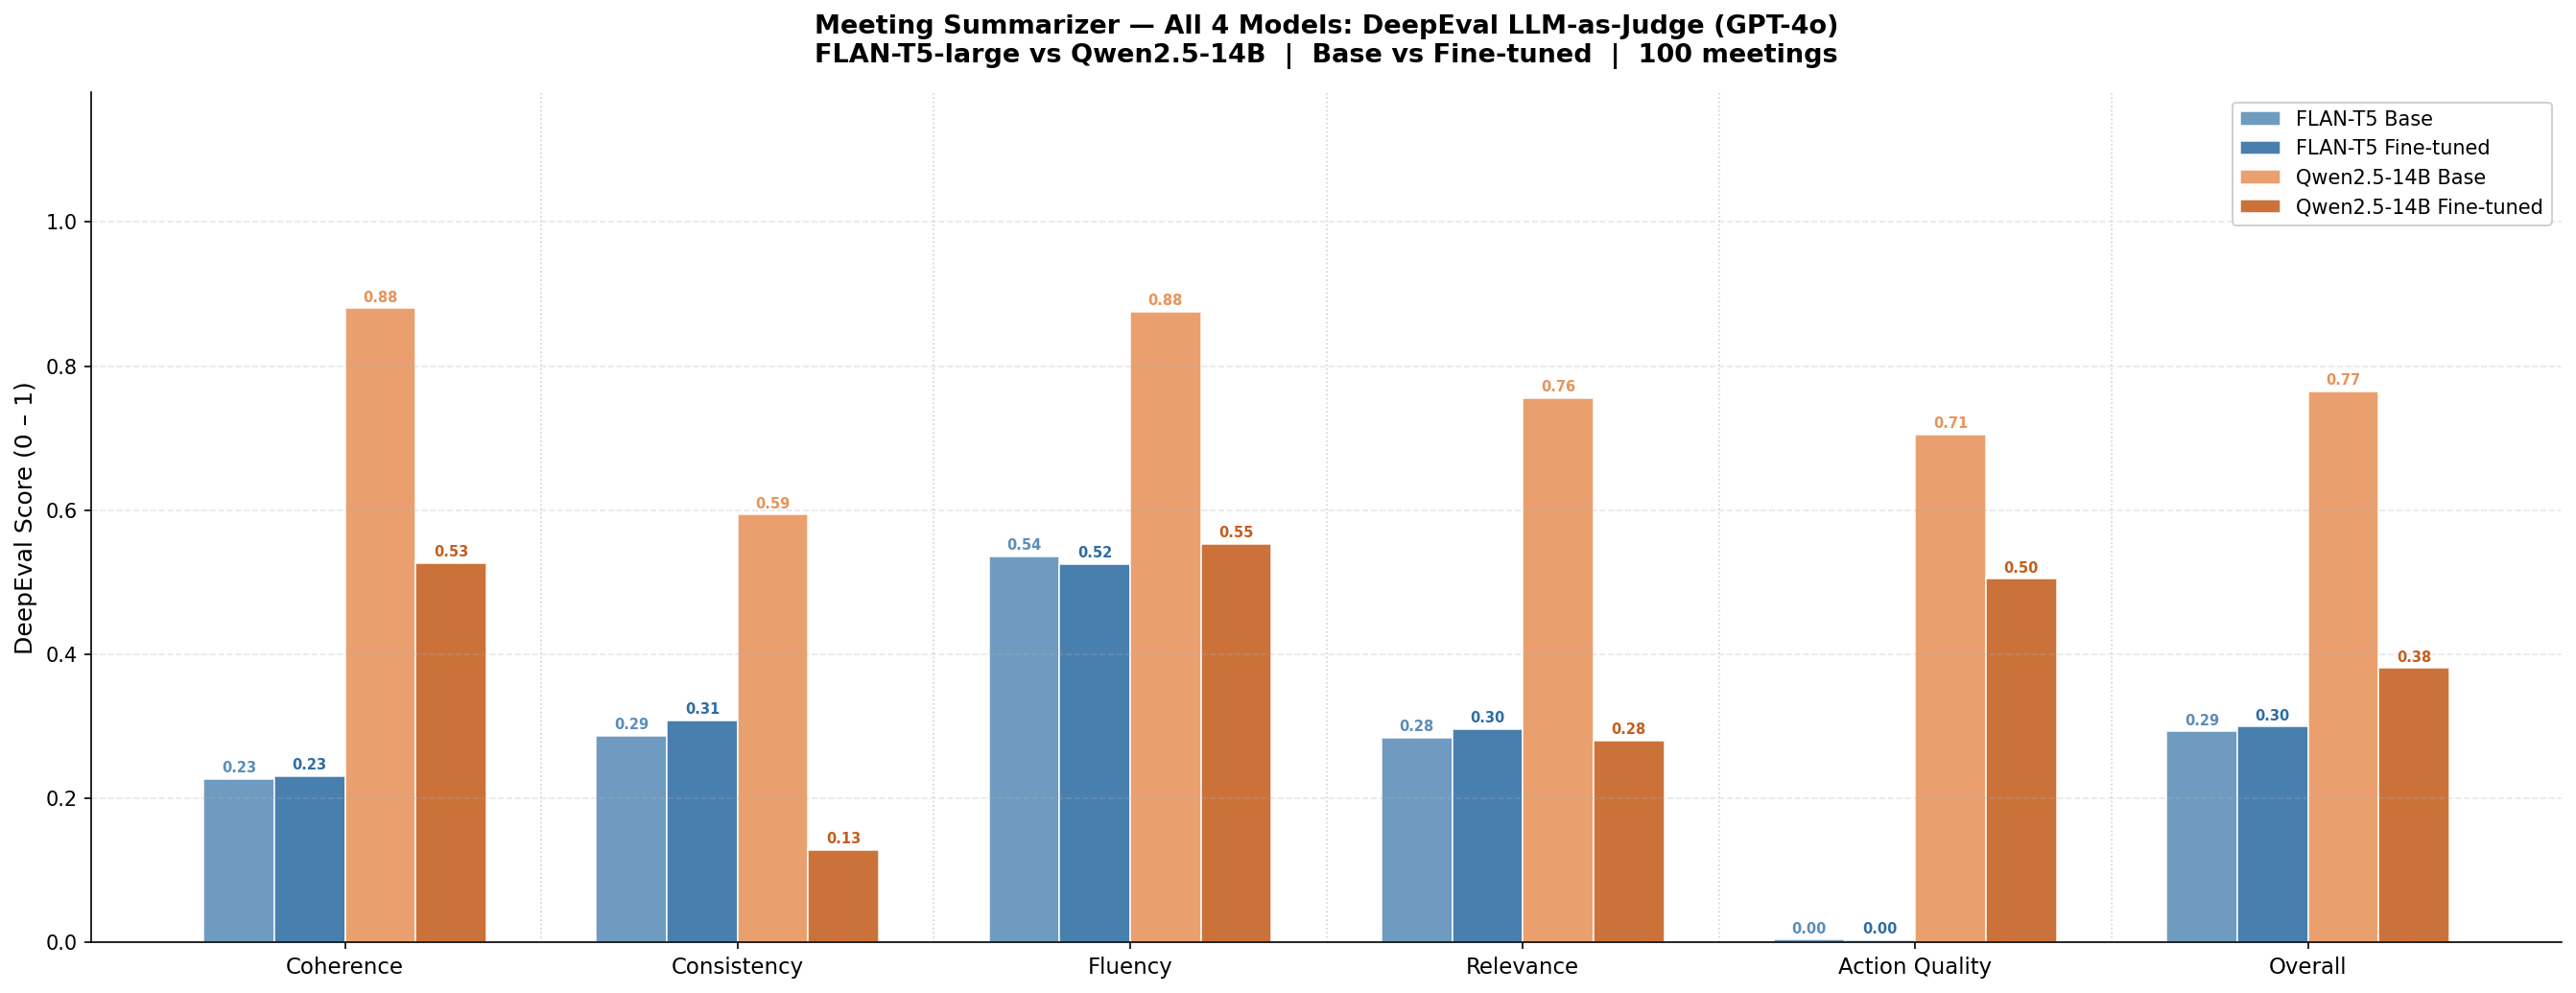

Chart saved: /content/drive/MyDrive/298-Capstone Project/DATA-298B/phase4_eval_outputs/plots/all_models_deepeval_comparison.png

Metric                    FLAN-T5 Base   FLAN-T5 FT    Qwen Base    Qwen FT     Best
-------------------------------------------------------------------------------------
Coherence                       0.2276       0.2313       0.8801     0.5264 Qwen2.5-14B Base
Consistency                     0.2868       0.3078       0.5940     0.1289 Qwen2.5-14B Base
Fluency                         0.5356       0.5249       0.8755     0.5534 Qwen2.5-14B Base
Relevance                       0.2845       0.2963       0.7555     0.2799 Qwen2.5-14B Base
Action Quality                  0.0040       0.0038       0.7050     0.5048 Qwen2.5-14B Base
Overall                         0.2930       0.2998       0.7652     0.3810 Qwen2.5-14B Base


In [15]:
# =============================================================================
# Cell 7d: Combined chart — all 4 models, GPT-4o DeepEval scores
# Run after Cell 10 (Qwen DeepEval) and Cell 10b (FLAN-T5 DeepEval)
# =============================================================================

print("Generating combined 4-model DeepEval comparison chart...")

# ── Gather DeepEval scores for all 4 models ───────────────────────────────────
all_model_data = {
    "FLAN-T5 Base":          ft5_base_deval,
    "FLAN-T5 Fine-tuned":    ft5_ft_deval,
    "Qwen2.5-14B Base":      base_deval,        # from Cell 11
    "Qwen2.5-14B Fine-tuned": ft_deval,         # from Cell 11
}
COLORS = ["#5B8DB8", "#2E6DA4", "#E8935A", "#C45E1E"]

PLOT_DIMS = [
    ("Coherence",      "deepeval_coherence"),
    ("Consistency",    "deepeval_consistency"),
    ("Fluency",        "deepeval_fluency"),
    ("Relevance",      "deepeval_relevance"),
    ("Action Quality", "deepeval_action_quality"),
    ("Overall",        "deepeval_overall"),
]

n_metrics = len(PLOT_DIMS)
n_models  = len(all_model_data)
x         = np.arange(n_metrics)
width     = 0.18
offsets   = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

fig, ax = plt.subplots(figsize=(18, 7))

for i, (model_name, df) in enumerate(all_model_data.items()):
    vals = []
    for _, key in PLOT_DIMS:
        val = df[key].mean() if key in df.columns else 0.0
        vals.append(val)

    bars = ax.bar(
        x + offsets[i], vals, width,
        label=model_name,
        color=COLORS[i],
        alpha=0.88,
        edgecolor="white",
        linewidth=0.8,
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.005,
            f"{h:.2f}", ha="center", va="bottom",
            fontsize=7, color=COLORS[i], fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in PLOT_DIMS], fontsize=11)
ax.set_ylabel("DeepEval Score (0 – 1)", fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_title(
    f"Meeting Summarizer — All 4 Models: DeepEval LLM-as-Judge (GPT-4o)\n"
    f"FLAN-T5-large vs Qwen2.5-14B  |  Base vs Fine-tuned  |  {DEEPEVAL_N} meetings",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Dividers between metrics
for xi in x[:-1]:
    ax.axvline(xi + 0.5, color="lightgray", linewidth=0.8, linestyle=":")

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "plots", "all_models_deepeval_comparison.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

# ── Print full comparison table ───────────────────────────────────────────────
print(f"\n{'='*85}")
print(f"{'Metric':<22} {'FLAN-T5 Base':>15} {'FLAN-T5 FT':>12} "
      f"{'Qwen Base':>12} {'Qwen FT':>10} {'Best':>8}")
print("-" * 85)
for label, key in PLOT_DIMS:
    scores = {
        name: (df[key].mean() if key in df.columns else float("nan"))
        for name, df in all_model_data.items()
    }
    best = max(scores, key=lambda k: scores[k] if not np.isnan(scores[k]) else -1)
    vals = list(scores.values())
    print(f"{label:<22} {vals[0]:>15.4f} {vals[1]:>12.4f} "
          f"{vals[2]:>12.4f} {vals[3]:>10.4f} {best:>8}")
print("=" * 85)

In [ ]:
# Cell 13: Save markdown summaries, ICS invites, action items CSV, final JSON

print("=" * 70)
print("Saving summaries, ICS files, action items CSV")
print("=" * 70)

# --- Markdown summaries ---
ft_scores_map = {r["meeting_id"]: r for r in ft_results}
for mid, entry in ft_cached.items():
    scores  = ft_scores_map.get(mid, {})
    md_path = os.path.join(OUTPUT_DIR, "summaries", f"meeting_{mid}_ft_summary.md")
    with open(md_path, "w", encoding="utf-8") as f:
        f.write(f"# Meeting Summary (Fine-tuned Qwen2.5-14B)\n\n")
        f.write(f"**Meeting ID:** {mid}\n\n## Scores\n\n")
        for label, key in [
            ("G-Eval Coherence",      "coherence"),
            ("G-Eval Consistency",    "consistency"),
            ("G-Eval Fluency",        "fluency"),
            ("G-Eval Relevance",      "relevance"),
            ("G-Eval Action Quality", "action_quality"),
            ("G-Eval Overall",        "geval_overall"),
            ("Production Score",      "production_score"),
            ("ROUGE-1",               "rouge1"),
            ("ROUGE-L",               "rougeL"),
        ]:
            f.write(f"- {label}: {scores.get(key, 0.0):.3f}\n")
        if BERT_AVAILABLE:
            f.write(f"- BERTScore F: {scores.get('bert_f', 0.0):.3f}\n")
        f.write(f"- JSON Valid: {entry.get('json_valid', False)}\n")
        f.write(f"- Gen Time: {entry.get('gen_time_sec', 0.0):.2f}s\n\n")
        f.write(f"## Generated Summary\n\n{entry.get('cleaned_output', '')}\n\n")
        f.write(f"## Reference\n\n{entry.get('reference', '')}\n")
print(f"Summaries saved: {len(ft_cached)} files")

# --- ICS calendar invites ---
n_ics = 0
for mid, entry in ft_cached.items():
    cleaned = entry.get("cleaned_output", "")
    actions, valid, _ = parse_actions_json(cleaned)
    if not actions:
        am = re.search(
            r"ACTIONS?:\s*(.*?)(?=\n(?:ABSTRACT|DECISIONS?|PROBLEMS?|ACTIONS_JSON|$)|\Z)",
            cleaned, re.DOTALL | re.IGNORECASE,
        )
        if am:
            for line in am.group(1).splitlines():
                line = line.strip()
                bm   = re.match(r"\[([^\]]+)\]\s*-\s*(.+?)(?:\s*-\s*Due:\s*(.+))?$", line)
                if bm:
                    actions.append({
                        "owner":    bm.group(1).strip(),
                        "task":     bm.group(2).strip(),
                        "deadline": (bm.group(3) or "TBD").strip(),
                    })
    if not actions:
        continue
    cal = Calendar()
    cal.add("prodid", "-//Phase4 14B//EN")
    cal.add("version", "2.0")
    try:
        ms = datetime.strptime(DEMO_DATE, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        ms = datetime.now()
    me = ms + timedelta(hours=1)
    ev = Event()
    ev.add("summary", f"Meeting {mid}")
    ev.add("dtstart", ms)
    ev.add("dtend",   me)
    abm = re.search(r"ABSTRACT:\s*(.*?)(?=\n\n|\Z)", cleaned, re.DOTALL)
    if abm:
        ev.add("description", abm.group(1).strip()[:500])
    cal.add_component(ev)
    for ai in actions:
        td = Todo()
        td.add("summary",     f"[{ai.get('owner','TBD')}] {str(ai.get('task',''))[:200]}")
        td.add("description", f"Owner: {ai.get('owner','TBD')}\nDeadline: {ai.get('deadline','TBD')}")
        if str(ai.get("deadline", "TBD")) != "TBD":
            try:
                due = dateparser.parse(str(ai["deadline"]))
                if due:
                    td.add("due", due)
            except Exception:
                pass
        cal.add_component(td)
    with open(os.path.join(OUTPUT_DIR, "ics", f"meeting_{mid}_invite.ics"), "wb") as f:
        f.write(cal.to_ical())
    n_ics += 1
print(f"ICS files saved : {n_ics}")

# --- Action items CSV ---
csv_rows = []
for mid, entry in ft_cached.items():
    cleaned  = entry.get("cleaned_output", "")
    data_src = test_map.get(mid, {}).get("data_source", "unknown")
    actions, valid, _ = parse_actions_json(cleaned)
    if not actions:
        am = re.search(
            r"ACTIONS?:\s*(.*?)(?=\n(?:ABSTRACT|DECISIONS?|PROBLEMS?|ACTIONS_JSON|$)|\Z)",
            cleaned, re.DOTALL | re.IGNORECASE,
        )
        if am:
            for line in am.group(1).splitlines():
                line = line.strip()
                bm   = re.match(r"\[([^\]]+)\]\s*-\s*(.+?)(?:\s*-\s*Due:\s*(.+))?$", line)
                if bm:
                    actions.append({
                        "owner":    bm.group(1).strip(),
                        "task":     bm.group(2).strip(),
                        "deadline": (bm.group(3) or "TBD").strip(),
                        "discussed_at_sec": 0.0,
                    })
    for ai in actions:
        csv_rows.append({
            "meeting_id":       mid,
            "data_source":      data_src,
            "poc_name":         str(ai.get("owner",    "TBD")),
            "task_description": str(ai.get("task",     "")),
            "deadline":         str(ai.get("deadline", "TBD")),
            "discussed_at_sec": ai.get("discussed_at_sec", 0.0),
            "json_source":      "ACTIONS_JSON" if valid else "ACTIONS_text",
            "model":            "finetuned_qwen2.5_14b",
        })

action_df = pd.DataFrame(csv_rows)
csv_path  = os.path.join(OUTPUT_DIR, "csv", "action_items_todo_list.csv")
action_df.to_csv(csv_path, index=False)
print(f"Action items CSV: {len(action_df)} rows, {action_df['meeting_id'].nunique()} meetings")
print(f"Unique POC names: {action_df['poc_name'].nunique()}")
print(f"CSV saved       : {csv_path}")
print()
print(action_df[["meeting_id","poc_name","task_description","deadline"]].head(5).to_string(index=False))

# --- Final JSON ---
eval_json = {
    "phase": "phase4_evaluation",
    "base_model": BASE_MODEL_NAME,
    "finetuned_model": PHASE4_MODEL_PATH,
    "num_test_meetings": len(test_records),
    "heuristic_geval": {
        "finetuned": {k: mean_of(ft_results,   k) for _, k in HEURISTIC_DISPLAY},
        "base":      {k: mean_of(base_results, k) for _, k in HEURISTIC_DISPLAY},
    },
    "action_items_total": len(action_df),
    "ics_files_generated": n_ics,
}
if DEEPEVAL_AVAILABLE and deval_rows:
    eval_json["deepeval_geval"] = {
        "finetuned": {k: ft_deval[k].mean()   if k in ft_deval.columns   else None for _, k in DEVAL_DISPLAY},
        "base":      {k: base_deval[k].mean() if k in base_deval.columns else None for _, k in DEVAL_DISPLAY},
    }
eval_json_path = os.path.join(OUTPUT_DIR, "full_evaluation_results.json")
with open(eval_json_path, "w", encoding="utf-8") as f:
    json.dump(eval_json, f, indent=2, ensure_ascii=False, default=str)

print()
print("=" * 70)
print("COMPLETE. All outputs saved to Drive.")
print("=" * 70)
print(f"  Summaries : {len(ft_cached)} markdown files")
print(f"  ICS files : {n_ics}")
print(f"  Action CSV: {len(action_df)} rows")
print(f"  Charts    : saved to {OUTPUT_DIR}/plots/")
print(f"  Eval JSON : {eval_json_path}")

Saving summaries, ICS files, action items CSV
